# Transformer Evaluation

Evaluate a saved TPrime Transformer run by pasting the exact training command,
the checkpoint path, and the dataset you want to score. The notebook recreates
the dataset configuration, loads the checkpoint, runs inference (GPU if
available), and plots the resulting confusion matrix.

In [ ]:

from pathlib import Path

# Edit these values for your run. GPU_DEVICE=None forces CPU.
RUN_COMMAND = """python TPrime_transformer_train.py   --snr_db 30   --wchannel None   --use-gpu   --postfix CLEAN_HO_4000   --raw_path ../data/CLEAN_HO_4000_train   --cp_path ./model_cp/CLEAN_HO_4000   --Layers 2   --Epochs 15   --Learning_rate 0.0002   --Batch_size 122   --Slice_length 128   --Sequence_length 64   --Positional_encoder False"""
MODEL_PATH = Path("/home/sat3737/Projects/t-prime/TPrime_transformer/model_cp/CLEAN_HO_4000/modelNone_30_lg_finetuned_best.pt")
EVAL_DATA_PATH = Path("/home/sat3737/Projects/t-prime/data/BOTH_HO_4000_eval")
DATASET_NAME = EVAL_DATA_PATH.name

GPU_DEVICE = 1          # 0,1, set to None for CPU inference
BATCH_SIZE = 256        # adjust for your memory budget
NUM_WORKERS = 4         # DataLoader workers (set to 0 if you hit notebook issues)


In [16]:

import json
import os
import shlex
import sys
from pathlib import Path
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "preprocessing").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessing.TPrime_dataset import TPrimeDataset_Transformer
from TPrime_transformer.model_transformer import TransformerModel, TransformerModel_v2

def parse_run_command(cmd: str) -> Dict[str, Any]:
    tokens = shlex.split(cmd.strip()) if cmd else []
    if not tokens:
        return {}
    parsed: Dict[str, Any] = {"_program": tokens[0]}
    i = 1
    while i < len(tokens):
        token = tokens[i]
        if token.startswith("--"):
            key = token.lstrip("-")
            if "=" in key:
                key, value = key.split("=", 1)
                parsed[key] = value
                i += 1
                continue
            values: List[str] = []
            i += 1
            while i < len(tokens) and not tokens[i].startswith("--"):
                values.append(tokens[i])
                i += 1
            if not values:
                parsed[key] = True
            elif len(values) == 1:
                parsed[key] = values[0]
            else:
                parsed[key] = values
        else:
            parsed.setdefault("_positionals", []).append(token)
            i += 1
    return parsed

def lookup_arg(parsed: Dict[str, Any], key: str, default: Any = None) -> Any:
    if key in parsed:
        return parsed[key]
    key_lower = key.lower()
    for k, v in parsed.items():
        if k.lower() == key_lower:
            return v
    return default

def str_to_bool(value: Any) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def ensure_list(value: Any) -> List[Any]:
    if value is None:
        return []
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]

def autodetect_protocols(root: Path) -> List[str]:
    if root is None or not root.exists():
        return []
    return sorted([p.name for p in root.iterdir() if p.is_dir() and not p.name.startswith('.')])

def resolve_device(preferred_index: Any):
    if preferred_index is None:
        print("Running on CPU (GPU index not provided)")
        return torch.device("cpu")
    if torch.cuda.is_available():
        count = torch.cuda.device_count()
        idx = int(preferred_index)
        if idx < 0 or idx >= count:
            print(f"Requested GPU {idx} not present. Falling back to GPU 0 out of {count} devices.")
            idx = 0
        device = torch.device(f"cuda:{idx}")
        torch.cuda.set_device(device)
        print(f"Using GPU device: {device}")
        return device
    print("CUDA not available; using CPU instead.")
    return torch.device("cpu")

def strip_module_prefix(state_dict: Dict[str, Any]) -> Dict[str, Any]:
    needs_strip = any(k.startswith('module.') for k in state_dict.keys())
    if not needs_strip:
        return state_dict
    return {k.replace('module.', '', 1) if k.startswith('module.') else k: v for k, v in state_dict.items()}

def build_eval_config(parsed: Dict[str, Any]) -> Dict[str, Any]:
    cfg: Dict[str, Any] = {}
    cfg['seq_len'] = int(lookup_arg(parsed, 'Sequence_length', 64))
    cfg['slice_len'] = int(lookup_arg(parsed, 'Slice_length', 128))
    cfg['layers'] = int(lookup_arg(parsed, 'Layers', 2))
    cfg['batch_size'] = int(lookup_arg(parsed, 'Batch_size', 128))
    cfg['postfix'] = lookup_arg(parsed, 'postfix', '')
    snr_raw = ensure_list(lookup_arg(parsed, 'snr_db', [30]))
    snr_vals = []
    for val in snr_raw:
        try:
            snr_vals.append(float(val))
        except (ValueError, TypeError):
            pass
    cfg['snr_db'] = snr_vals or [30.0]
    wchannel = lookup_arg(parsed, 'wchannel', None)
    if isinstance(wchannel, list):
        wchannel = wchannel[0]
    if isinstance(wchannel, str) and wchannel.lower() in {'none', 'null'}:
        wchannel = None
    cfg['wchannel'] = wchannel
    cfg['positional_encoder'] = str_to_bool(lookup_arg(parsed, 'Positional_encoder', False))
    cfg['cls_token'] = bool(lookup_arg(parsed, 'cls_token', False))
    cfg['script'] = parsed.get('_program')
    cfg['raw_path'] = lookup_arg(parsed, 'raw_path')
    cfg['protocols'] = lookup_arg(parsed, 'protocols')
    return cfg

def build_model(model_path: Path, cfg: Dict[str, Any], nclasses: int, device: torch.device) -> torch.nn.Module:
    ModelClass = TransformerModel_v2 if cfg.get('cls_token') else TransformerModel
    d_model = 2 * cfg['slice_len']
    model = ModelClass(classes=nclasses, d_model=d_model, seq_len=cfg['seq_len'], nlayers=cfg['layers'], use_pos=cfg['positional_encoder'])
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict') if isinstance(checkpoint, dict) else None
    if state_dict is None and isinstance(checkpoint, dict):
        state_dict = checkpoint.get('state_dict')
    if state_dict is None:
        state_dict = checkpoint if isinstance(checkpoint, dict) else checkpoint
    state_dict = strip_module_prefix(state_dict)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()
    return model

def evaluate_model(model: torch.nn.Module, dataloader: DataLoader, device: torch.device, nclasses: int, label_names: List[str]) -> Dict[str, Any]:
    model.eval()
    total = 0
    correct = 0
    y_true: List[np.ndarray] = []
    y_pred: List[np.ndarray] = []
    with torch.no_grad():
        for batch in dataloader:
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs.float())
            preds = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            y_true.append(targets.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
    if total == 0:
        raise ValueError("Evaluation dataset is empty.")
    y_true_np = np.concatenate(y_true)
    y_pred_np = np.concatenate(y_pred)
    labels = list(range(nclasses))
    conf = confusion_matrix(y_true_np, y_pred_np, labels=labels)
    row_sums = conf.sum(axis=1, keepdims=True)
    conf_percent = np.divide(conf, row_sums, out=np.zeros_like(conf, dtype=float), where=row_sums != 0) * 100.0
    accuracy = correct / total
    safe_names = label_names if len(label_names) == nclasses else [f"Class {i}" for i in range(nclasses)]
    report = classification_report(y_true_np, y_pred_np, labels=labels, target_names=safe_names, zero_division=0)
    per_class_acc = dict(zip(safe_names, np.diag(conf_percent)))
    return {
        'accuracy': accuracy,
        'confusion_matrix': conf,
        'confusion_matrix_percent': conf_percent,
        'classification_report': report,
        'per_class_accuracy': per_class_acc
    }


In [17]:

parsed_args = parse_run_command(RUN_COMMAND)
eval_config = build_eval_config(parsed_args)

if eval_config.get('protocols') is None:
    eval_config['protocols'] = autodetect_protocols(EVAL_DATA_PATH)
elif not isinstance(eval_config['protocols'], list):
    eval_config['protocols'] = ensure_list(eval_config['protocols'])

print(json.dumps({'parsed_args': parsed_args, 'eval_config': eval_config}, indent=2))


{
  "parsed_args": {
    "_program": "python",
    "_positionals": [
      "TPrime_transformer_train.py"
    ],
    "snr_db": "30",
    "wchannel": "None",
    "use-gpu": true,
    "postfix": "CLEAN_HO_4000",
    "raw_path": "../data/CLEAN_HO_4000_train",
    "cp_path": "./model_cp/CLEAN_HO_4000",
    "Layers": "2",
    "Epochs": "15",
    "Learning_rate": "0.0002",
    "Batch_size": "122",
    "Slice_length": "128",
    "Sequence_length": "64",
    "Positional_encoder": "False"
  },
  "eval_config": {
    "seq_len": 64,
    "slice_len": 128,
    "layers": 2,
    "batch_size": 122,
    "postfix": "CLEAN_HO_4000",
    "snr_db": [
      30.0
    ],
    "wchannel": null,
    "positional_encoder": false,
    "cls_token": false,
    "script": "python",
    "raw_path": "../data/CLEAN_HO_4000_train",
    "protocols": [
      "AIR",
      "INS",
      "MIN",
      "MP1",
      "MP2",
      "PHA"
    ]
  }
}


In [18]:

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {MODEL_PATH}")
if not EVAL_DATA_PATH.exists():
    raise FileNotFoundError(f"Eval dataset path not found: {EVAL_DATA_PATH}")

device = resolve_device(GPU_DEVICE)
protocols = eval_config['protocols'] or autodetect_protocols(EVAL_DATA_PATH)
if not protocols:
    raise RuntimeError(f"Could not infer protocol folders under {EVAL_DATA_PATH}")

eval_dataset = TPrimeDataset_Transformer(
    protocols=protocols,
    ds_type='test',
    file_postfix=eval_config['postfix'],
    ds_path=str(EVAL_DATA_PATH),
    snr_dbs=eval_config['snr_db'],
    seq_len=eval_config['seq_len'],
    slice_len=eval_config['slice_len'],
    slice_overlap_ratio=0,
    raw_data_ratio=1.0,
    override_gen_map=False,
    apply_wchannel=eval_config['wchannel']
)

ds_info = eval_dataset.info()
label_names = protocols if len(protocols) == ds_info['nclasses'] else [f"Class {i}" for i in range(ds_info['nclasses'])]

dataloader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda')
)

model = build_model(MODEL_PATH, eval_config, ds_info['nclasses'], device)

print(f"Evaluating {MODEL_PATH.name} on {len(eval_dataset)} slices across {ds_info['nclasses']} classes -> device {device}")


Using GPU device: cuda:1
Evaluating modelNone_30_lg_finetuned_best.pt on 1920 slices across 6 classes -> device cuda:1


In [19]:
results = evaluate_model(model, dataloader, device, ds_info['nclasses'], label_names)

print(f"Overall accuracy: {results['accuracy'] * 100:.2f}%")
print("\nPer-class accuracy (%):")
for name, acc in results['per_class_accuracy'].items():
    print(f"  {name:>10s}: {acc:.2f}")


Overall accuracy: 58.39%

Per-class accuracy (%):
         AIR: 94.94
         INS: 45.37
         MIN: 12.17
         MP1: 80.29
         MP2: 19.68
         PHA: 99.70


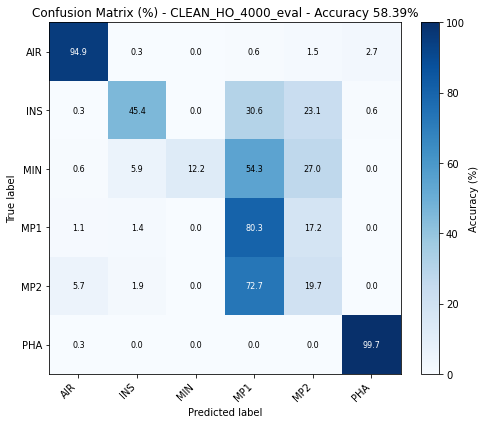

In [20]:

cm_percent = results['confusion_matrix_percent']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_percent, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f"Confusion Matrix (%) - {DATASET_NAME} - Accuracy {results['accuracy'] * 100:.2f}%")

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        value = cm_percent[i, j]
        color = 'white' if value > 60 else 'black'
        ax.text(j, i, f"{value:.1f}", ha='center', va='center', color=color, fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Accuracy (%)')
plt.tight_layout()
plt.show()


In [21]:

print(results['classification_report'])


              precision    recall  f1-score   support

         AIR       0.93      0.95      0.94       336
         INS       0.83      0.45      0.59       324
         MIN       1.00      0.12      0.22       337
         MP1       0.30      0.80      0.44       279
         MP2       0.22      0.20      0.21       315
         PHA       0.97      1.00      0.98       329

    accuracy                           0.58      1920
   macro avg       0.71      0.59      0.56      1920
weighted avg       0.72      0.58      0.57      1920

